# Tensile Tester Load-vs-Time Practice

You have raw load-cell readings from 36 tensile-test runs. Your goal is to clean the readings, visualize the tests, apply test limits, and create a pass/fail report for every unit.

Write the code yourself in the cells below. The comments describe the next task without giving away the implementation.

## Files and pass criteria

- `data/tensile_load_time_raw.csv`: one load reading every 10 seconds for each test run.
- `data/tensile_test_limits.csv`: allowed peak-load and duration ranges for each material.

A unit passes only when all of these are true:

1. Its peak load is within its material's minimum and maximum limits.
2. Its test duration is within its material's minimum and maximum limits.
3. Every recorded sensor status for that unit is `OK`.

The raw data intentionally contains whitespace inconsistencies, alternate material spellings, duplicate readings, an invalid time point, missing/invalid load entries, and sensor-status problems.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

raw_data_path = "data/tensile_load_time_raw.csv"
limits_path = "data/tensile_test_limits.csv"

## 1. Load and inspect the raw data

Start by loading both CSV files. Before changing anything, inspect column names, data types, a few rows, unique material values, sensor-status values, and missing values.

In [6]:
# Read the raw readings CSV into a DataFrame named raw_df.
raw_df = pd.read_csv("data/tensile_load_time_raw.csv")
# Read the limits CSV into a DataFrame named limits_df.
limits_df = pd.read_csv("data/tensile_test_limits.csv")
# Inspect both DataFrames: head(), info(), describe(), and useful unique-value checks.
raw_df.head()
raw_df.info()
raw_df.describe()
raw_df.isna().sum()

# and now limits:
limits_df.head()
limits_df.info()
limits_df.describe()
# What looks inconsistent or unsuitable for numeric calculations?
print(raw_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0    Test Run ID           423 non-null    str    
 1   Unit ID                423 non-null    str    
 2   Material               423 non-null    str    
 3   Test Date              423 non-null    str    
 4   Machine ID             423 non-null    str    
 5   Sample Thickness (mm)  423 non-null    float64
 6   Elapsed Time (s)       423 non-null    int64  
 7   Load (kN)              422 non-null    str    
 8   Extension (mm)         423 non-null    float64
 9   Operator               423 non-null    str    
 10  Sensor Status          423 non-null    str    
dtypes: float64(2), int64(1), str(8)
memory usage: 36.5 KB
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  

## 2. Clean the readings

Work on a copy so `raw_df` remains available for comparison. Decide and document how you handle each issue.

In [ ]:
# Make a copy of raw_df named clean_df.
clean_df = raw_df.copy()
# Strip spaces from every column name.
clean_df.columns = clean_df.columns.str.strip()
clean_df.columns
# Strip spaces from Unit ID and Test Run ID values.
clean_df["Unit ID"] = clean_df["Unit ID"].astype("string").str.strip().str.replace(" ", "", regex=False)
clean_df["Test Run ID"] = clean_df["Test Run ID"].astype("string").str.strip().str.replace(" ", "", regex=False)
# Standardize Material values so alternate spellings map to the same three materials.
def standardize(material:pd.Series) -> pd.Series:
    material = material.str.strip().str.lower()
    material = material.replace({"aluminum": "Aluminum", "aluminium": "Aluminum", "alum": "Aluminum",
                                 "steel": "Steel", "stainless steel": "Steel", "stainless": "Steel",
                                 "titanium": "Titanium", "titanium alloy": "Titanium"})
    return material

clean_df["Material"] = standardize(clean_df["Material"])
# Convert Test Date to a datetime column; the source uses more than one date format.
clean_df["Test Date"] = pd.to_datetime(clean_df["Test Date"],format="mixed")
clean_df.head()
# Convert elapsed time, load, extension, and thickness to numeric values.
clean_df["Elapsed Time (s)"] = pd.to_numeric(clean_df["Elapsed Time (s)"], errors="coerce")
clean_df["Load (kN)"] = pd.to_numeric(clean_df["Load (kN)"], errors="coerce")
clean_df["Extension (mm)"] = pd.to_numeric(clean_df["Extension (mm)"], errors="coerce")
clean_df["Sample Thickness (mm)"] = pd.to_numeric(clean_df["Sample Thickness (mm)"], errors="coerce")
# Find duplicated readings. Decide whether to remove them and explain why.
clean_df[clean_df.duplicated(keep=False)]
# drop them; they are completely identical across all rows.
clean_df.drop_duplicates(keep=False)
# Inspect invalid or missing load values and non-OK sensor statuses before removing any rows.
clean_df = clean_df.dropna(subset="Load (kN)")
clean_df.isna().sum() # check that there are no more missing load values
# Keep a clean, traceable version of the data.

Test Run ID              0
Unit ID                  0
Material                 0
Test Date                0
Machine ID               0
Sample Thickness (mm)    0
Elapsed Time (s)         0
Load (kN)                0
Extension (mm)           0
Operator                 0
Sensor Status            0
dtype: int64

## 3. Filter the data

Create focused DataFrames for valid readings and for one selected test run. Do not accidentally remove a unit from the final report merely because it has a bad sensor reading; it still needs a fail result.

In [35]:
# Filter out impossible elapsed-time values for plotting and numeric summaries.
clean_df = clean_df[(clean_df["Elapsed Time (s)"] > 0)]
# Create a DataFrame containing only readings with usable numeric load values.
loadusable = clean_df[(clean_df["Load (kN)"].notna()) & (clean_df["Load (kN)"] > 0)]
# Choose one Test Run ID and filter its readings into one_unit_df.
onetest = loadusable["Test Run ID"].unique()[0]
one_unit_df = loadusable[loadusable["Test Run ID"] == onetest]
# Sort one_unit_df by elapsed time.
one_unit_df = one_unit_df.sort_values("Elapsed Time (s)")
# Compare the raw and filtered row counts for your chosen unit.
print(f"Raw row count for unit {onetest}: {loadusable[loadusable['Test Run ID'] == onetest].shape[0]}")
print(f"Filtered row count for unit {onetest}: {one_unit_df.shape[0]}")

Raw row count for unit TT-2026-001: 11
Filtered row count for unit TT-2026-001: 11


## 4. Graph the tensile tests

Use labels, titles, and units on every graph. Start simple, then compare multiple units.

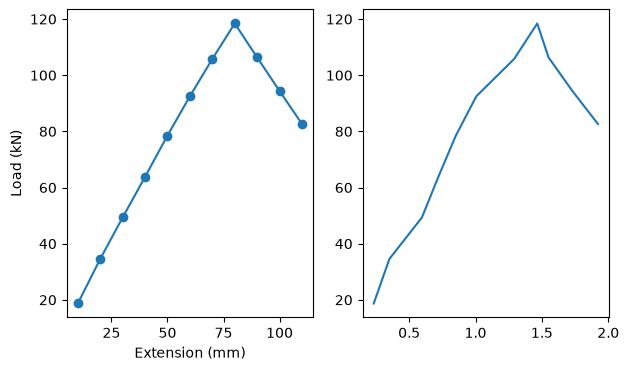

In [ ]:
# Make a line graph of Load (kN) versus Elapsed Time (s) for one_unit_df.
one_unit_df.head()
fig, ax = plt.subplots(1,2,figsize=(7,4))
ax[0].plot(one_unit_df["Elapsed Time (s)"],one_unit_df["Load (kN)"], marker="o")
ax[0].set_xlabel("Elapsed Time (s)")
ax[0].set_ylabel("Load (kN)")

# Add markers so you can see the individual measurements.
# Make a second graph of Load (kN) versus Extension (mm) for the same unit.
ax[1].plot(one_unit_df["Extension (mm)"], one_unit_df["Load (kN)"])
ax[0].set_xlabel("Extension (mm)")
ax[0].set_ylabel("Load (kN)")
plt.show()

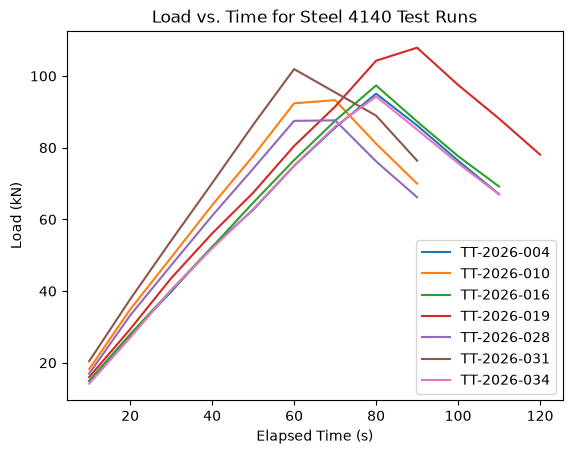

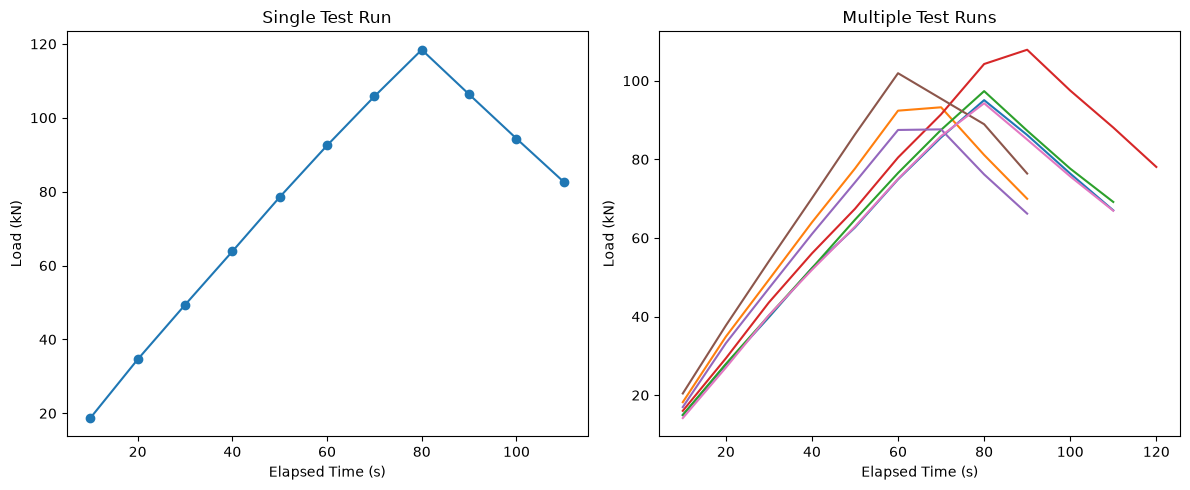

In [57]:
# Filter to one material.
steelfilter = loadusable["Material"] == "steel 4140"
steeltests = loadusable[steelfilter]
steeltests.head(35)
steeltests_load = steeltests["Load (kN)"]
steeltests_time = steeltests["Elapsed Time (s)"]
# Make a multi-series load-vs-time graph: one line per Test Run ID.
for testid in steeltests["Test Run ID"].unique():
    subset = steeltests[steeltests["Test Run ID"] == testid]
    plt.plot(subset["Elapsed Time (s)"], subset["Load (kN)"], label=testid)
plt.xlabel("Elapsed Time (s)")
plt.ylabel("Load (kN)")
plt.title("Load vs. Time for Steel 4140 Test Runs")
# Add a legend. Is it still readable? If not, try graphing a smaller subset of runs.
plt.legend()
# Make a subplot figure containing the single-unit graph and the multi-unit graph.
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Single-unit graph
ax[0].plot(one_unit_df["Elapsed Time (s)"],one_unit_df["Load (kN)"], marker="o")
ax[0].set_xlabel("Elapsed Time (s)")
ax[0].set_ylabel("Load (kN)")
ax[0].set_title("Single Test Run")
# Multi-unit graph
for testid in steeltests["Test Run ID"].unique():
    subset = steeltests[steeltests["Test Run ID"] == testid]
    ax[1].plot(subset["Elapsed Time (s)"], subset["Load (kN)"], label=testid)
ax[1].set_xlabel("Elapsed Time (s)")
ax[1].set_ylabel("Load (kN)")
ax[1].set_title("Multiple Test Runs")
plt.tight_layout()
plt.show()

## 5. Make one summary row per unit

The readings table has many rows per unit. Create a summary table with exactly one row for every test run. It should preserve the material and unit identity, calculate each run's peak load and observed duration, and record whether every sensor status was OK.

In [ ]:
# Group the clean data by Test Run ID and Unit ID.
# Calculate peak load and duration for each unit.
# Carry forward the material for each unit.
# Calculate a Boolean sensor_ok value: True only when all sensor statuses are OK.
# Name this one-row-per-unit table unit_summary.
# Check that unit_summary has one row for every original test run.

## 6. Apply limits

Join the material-level limits onto `unit_summary`. Each unit should gain its own minimum/maximum peak-load and duration limits.

In [ ]:
# Clean the Material column in limits_df the same way as the readings data.
# Merge limits_df into unit_summary using Material.
# Create separate Boolean columns for peak-load limits and duration limits.
# Combine those two checks with sensor_ok into one overall pass/fail condition.
# Create a Pass/Fail column from that overall condition.
# Verify that every unit received limits after the merge.

In [ ]:
# For one selected unit, make a load-vs-time graph.
# Draw horizontal lines at that unit's minimum and maximum peak-load limits.
# Use different colors and labels for the measured load and each limit.
# Make a separate bar chart of each unit's peak load, colored by Pass/Fail.

## 7. Flag failures and write test statements

Create a focused failure report. A useful report explains *why* each unit failed, rather than only giving it a label.

In [ ]:
# Filter unit_summary to create failed_units.
# Add a failure-reason column. Include low/high peak load, short/long duration, and sensor problems.
# Create a readable statement for every unit, for example:
# "UT-001: PASS - peak load and duration are within limits; sensor status is OK."
# Print or display the statements for failed units first.
# Count passes and failures by material and by machine.

In [ ]:
# Select useful columns for a final test report.
# Save the report as data/tensile_test_report.csv.
# Read the saved file back in and verify its row count and columns.

## Stretch goals

- Add a plot that highlights failed units with a different color.
- Build a function that accepts a DataFrame and a Test Run ID, then returns a load-vs-time graph with limits.
- Build a small class that stores the cleaned readings and limits, then provides methods for summarizing and reporting failures.
- Compare the pass rate across machines and operators.